## Binomial Distribution

The binomial distribution models:
- The number of “successes” in a fixed number of independent trials, where each trial has the same success probability.

Formally, if

$$
K \sim \mathrm{Binomial}(M, p).
$$
then:

- You perform $M$ trials
- Each trial is independent
- Each trial has two outcomes (e.g. success/failure)
- The probability of “success” on each trial is $p$

The probability of getting exactly $k$ successes is:

$$
\Pr(K = k) = \binom{M}{k} p^k (1-p)^{M-k}.
$$

Think of:

- flipping a biased coin M times
- “success” = heads
- coin comes up heads with probability p

Then $K$ = number of heads follows a binomial distribution.


## Why Ensembles Work

Consider binary predictions $h_1(x), \dots, h_M(x) \in \{0,1\}$ from $M$ classifiers, each with error rate $p = \Pr(h_j(x) \neq y)$ and $p < 0.5$.

For majority voting, the ensemble prediction is:
$$
H(x) = \text{mode}\big(h_1(x), \dots, h_M(x)\big).
$$

The probability that the ensemble misclassifies is the probability that **more than half** of the individual classifiers are wrong. If we (approximately) treat individual errors as independent, then the number of wrong classifiers for a given $x$ follows a binomial distribution:
$$
K \sim \mathrm{Binomial}(M, p).
$$

The ensemble is wrong when $K$ is at least half of $M$:
$$
\Pr(H(x) \neq y) =
\sum_{k=\lceil \frac{M+1}{2} \rceil}^{M}
\binom{M}{k} p^k (1-p)^{M-k}.
$$

### Tiny Example: 3 Classifiers with 30% Error

Let $M = 3$ and $p = 0.3$. Each classifier is wrong with probability $0.3$ and correct with probability $0.7$.

The ensemble (majority vote) is wrong if **at least 2** out of 3 classifiers are wrong:
- Case 1: exactly 2 wrong, 1 correct:
  $$
  \Pr(K = 2) = \binom{3}{2} (0.3)^2 (0.7)^1 = 3 \cdot 0.09 \cdot 0.7 = 0.189.
  $$
- Case 2: exactly 3 wrong:
  $$
  \Pr(K = 3) = \binom{3}{3} (0.3)^3 (0.7)^0 = 1 \cdot 0.027 = 0.027.
  $$

So the probability that the **ensemble** is wrong is:
$$
\Pr(H(x) \neq y) = \Pr(K = 2) + \Pr(K = 3) = 0.189 + 0.027 = 0.216.
$$

Each individual classifier has error $p = 0.3$ (30%), but the 3‑way majority vote has error about $0.216$ (21.6%). The ensemble is more accurate than any single classifier.

As you increase $M$ (and keep $p < 0.5$ and errors not perfectly correlated), the ensemble error continues to decrease. This is why large ensembles can be very strong, even if each individual model is only moderately good.

But keep in mind that:
- Individual models should be **better than random** ($p < 0.5$).
- Their errors should be **diverse** (not perfectly correlated).

In [1]:
import numpy as np

In [29]:
p = 0.7
M = 3
n_trials = 100_000
rng = np.random.default_rng(seed=42)

preds = rng.random((n_trials, M)) < 0.7
preds

array([[False,  True, False],
       [ True,  True, False],
       [False, False,  True],
       ...,
       [ True, False,  True],
       [False,  True,  True],
       [ True,  True,  True]], shape=(100000, 3))

In [30]:
individual_acc = preds.mean()
individual_acc

np.float64(0.6995533333333334)

In [32]:
ensemble_preds = preds.sum(axis=1) > M // 2 # 1
ensemble_preds

array([False,  True, False, ...,  True,  True,  True], shape=(100000,))

In [33]:
ensemble_acc = ensemble_preds.mean()
ensemble_acc

np.float64(0.78435)

## Voting Classifiers

### Hard vs Soft Voting

Given base classifiers $h_1, \dots, h_M$, a **hard voting** classifier predicts:
$$
H_{\text{hard}}(x) = \text{mode}\big(h_1(x), \dots, h_M(x)\big).
$$

If classifiers output class probabilities $p_j(y \mid x)$, a **soft voting** classifier predicts:
$$
H_{\text{soft}}(x) = \arg\max_y \frac{1}{M} \sum_{j=1}^{M} p_j(y \mid x).
$$

Soft voting weights high‑confidence predictions more heavily and usually performs better, provided all base estimators can estimate probabilities.

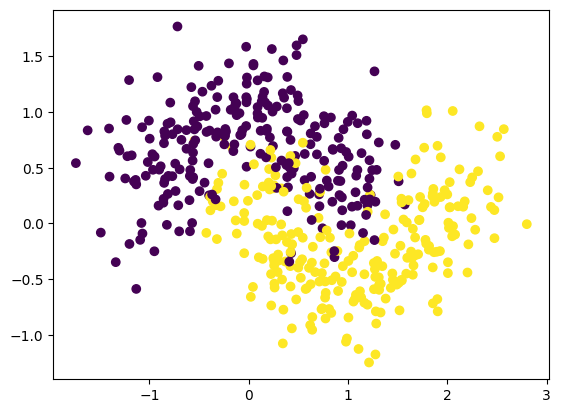

In [4]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=123)),
        ('rf', RandomForestClassifier(random_state=123)),
        ('svc', SVC(random_state=123))
    ]
)
voting_clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [13]:
y_pred = voting_clf.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0])

In [14]:
y_test

array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0])

In [17]:
voting_clf.estimators_

[LogisticRegression(random_state=123),
 RandomForestClassifier(random_state=123),
 SVC(random_state=123)]

In [18]:
[clf.predict(X_test[:1]) for clf in voting_clf.estimators_]

[array([1]), array([1]), array([0])]

In [15]:
voting_clf.named_estimators_

{'lr': LogisticRegression(random_state=123),
 'rf': RandomForestClassifier(random_state=123),
 'svc': SVC(random_state=123)}

In [16]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


In [19]:
voting_clf.score(X_test, y_test)

0.904

In [20]:
voting_clf.voting = "soft"
voting_clf.named_estimators["svc"].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.928

## Bagging and Pasting

### Idea

Given a base estimator $h$ (often a decision tree), bagging builds an ensemble:
$$
H(x) = \text{aggregate}\big(h_1(x), \dots, h_M(x)\big)
$$
where each $h_m$ is trained on a **different subset of the training data**.

- **Bagging** (Bootstrap Aggregating): sample **with replacement** from the training set for each model.
- **Pasting**: sample **without replacement**.

For classification, aggregation is usually majority vote; for regression, it is typically the mean.

This reduces variance by averaging many high‑variance models trained on different data subsets.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), 
    n_estimators=500,
    max_samples=100, 
    bootstrap=True,
    n_jobs=-1, 
    random_state=123
)
bag_clf.fit(X_train, y_train)
bag_clf.score(X_test, y_test)

0.912


Replace `bootstrap=True` with `bootstrap=False` to perform pasting instead of bagging.

### Out‑of‑Bag (OOB) Evaluation

In bagging, each model is trained on a bootstrap sample of size $m$ drawn from a dataset of size $m$. Pick a specific data point $x_i$.

On one draw:

- Probability it is chosen: $\frac{1}{m}$
- Probability it is NOT chosen: $1−\frac{1}{m}$

We draw $m$ times. Since draws are independent:

$$\text{Pr}⁡(x_i \text{ is never selected})=\left(1−\frac{1}{m}\right)^m$$

The probability that a given instance is **not** selected in one bootstrap sample is:
$$\left(1−\frac{1}{m}\right)^m = \left[\left(1+\frac{-1}{m}\right)^m\right]\to e^{-1} \approx 0.37 \quad \text{as} \quad m \to \infty
$$

So roughly:
- 63% of instances appear in a given model’s training set
- 37% are **out‑of‑bag** for that model

These OOB instances can be used as a validation set for that model. Averaging across all models yields an **OOB score**:

In [22]:
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

bag_clf.fit(X_train, y_train)
oob_acc = bag_clf.oob_score_
test_acc = bag_clf.score(X_test, y_test)

oob_acc, test_acc

(0.896, 0.92)

OOB evaluation provides an unbiased performance estimate without using a separate validation set.


## Random Forests

Random Forests specialize bagging to decision trees and add **feature randomness**.

### Algorithm (Classification)

For each of $M$ trees:
- Draw a bootstrap sample of the training data.
- Grow a decision tree:
  - At each node, randomly select a subset of features of size $d_{\text{sub}}$:
    - For classification, often $d_{\text{sub}} = \sqrt{d}$.
  - Among these features, choose the best split according to impurity decrease (e.g., Gini).

Prediction:
- For classification: majority vote over trees.
- For regression: average prediction over trees.

The additional feature randomness decorrelates trees, further reducing variance of the ensemble.


In [23]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(
    n_estimators=500,
    max_leaf_nodes=16,
    n_jobs=-1,
    random_state=42
)

rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)

y_pred_rf

array([0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0])

Mathematically, this is equivalent to:
- A `BaggingClassifier` with a `DecisionTreeClassifier` base estimator
- Bootstrapping enabled
- Random feature subsets at each split



### Feature Importance

For tree‑based ensembles, scikit‑learn estimates feature importance via **impurity decrease**:

For each tree, for each split $s$ using feature $j$:
- Let $I_{\text{parent}}$ be impurity before split
- Let $I_L, I_R$ be impurity of left and right children
- Let $w_L, w_R$ be fractions of samples going to each child
- Impurity decrease:
  $$
  \Delta I_s = I_{\text{parent}} - (w_L I_L + w_R I_R)
  $$

Feature importance for $j$ sums these decreases over all splits using $j$, averaged across trees and normalized.

For image‑like data (e.g., MNIST), reshaping `feature_importances_` to 2D gives an importance heatmap.

In [24]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500, random_state=42)
rnd_clf.fit(iris.data, iris.target)

for score, name in zip(rnd_clf.feature_importances_, iris.data.columns):
    print(round(score, 2), name)

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


## Boosting

Boosting builds ensembles **sequentially**, where each new learner focuses on correcting the errors of the previous ones. This creates strong models from many weak learners.

We will focus on:
- AdaBoost (Adaptive Boosting)
- Gradient Boosting (including HistGradientBoosting)

### AdaBoost (Binary Classification)

AdaBoost maintains a distribution of **weights** over training instances and iteratively trains base classifiers (often shallow trees or other weak learners).

Given data $(x_i, y_i)$ with $y_i \in \{-1, +1\}$:

1. Initialize weights:
   $$
   w_i^{(1)} = \frac{1}{m}.
   $$
2. For $t = 1, \dots, T$:
   - Train base classifier $h_t$ on weighted data.
   - Compute weighted error:
     $$
     \epsilon_t = \frac{\sum_{i=1}^m w_i^{(t)} [h_t(x_i) \neq y_i]}
                       {\sum_{i=1}^m w_i^{(t)}}.
     $$
   - Compute learner weight:
     $$
     \alpha_t = \eta \cdot \log \frac{1 - \epsilon_t}{\epsilon_t},
     $$
     where $\eta$ is the learning rate.
   - Update sample weights:
     $$
     w_i^{(t+1)} = w_i^{(t)} \exp\big(\alpha_t [h_t(x_i) \neq y_i]\big),
     $$
     then normalize so weights sum to 1.

Final prediction:
$$
H(x) = \text{sign}\left(\sum_{t=1}^T \alpha_t h_t(x)\right).
$$


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=30,
    learning_rate=0.5,
    algorithm="SAMME",
    random_state=42
)

ada_clf.fit(X_train, y_train)
acc = ada_clf.score(X_test, y_test)

Hyperparameters:
- `n_estimators`: number of boosting rounds $T$
- `learning_rate` $\eta$: scales $\alpha_t$; smaller values need more estimators
- Base estimator complexity (e.g. tree depth) controls bias/variance



### Gradient Boosting (Regression)

Gradient Boosting interprets boosting as **gradient descent** in function space on a loss $L(y, f(x))$.

Idea:
- Start with a simple model $f_0(x)$.
- At each step, fit a weak learner to (approximate) the **negative gradient** of the loss with respect to current predictions.

For squared loss:
$$
L(y, f(x)) = \frac{1}{2} (y - f(x))^2,
$$
the negative gradient is:
$$
-\frac{\partial L}{\partial f} = y - f(x),
$$
which is just the residual error.

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

m = 100
rng = np.random.default_rng(seed=42)
X = rng.random((m, 1)) - 0.5
noise = 0.05 * rng.standard_normal(m)
y = 3 * X[:, 0] ** 2 + noise

tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

y2 = y - tree_reg1.predict(X)
y2

array([ 0.15406516, -0.12514572, -0.07696399,  0.09074453, -0.09834911,
        0.27169237,  0.06682165,  0.14414718,  0.01693008, -0.10064629,
        0.00101556,  0.01618578, -0.0072666 , -0.11942131, -0.11118094,
        0.05981395, -0.07853433, -0.03032046, -0.11017291, -0.03798015,
        0.18883749, -0.039559  ,  0.16966175,  0.02876316,  0.15241265,
       -0.00277129, -0.04600126,  0.06757658,  0.08124518, -0.0499967 ,
        0.05665866,  0.16553398, -0.01955937, -0.10957154, -0.05654121,
       -0.07229425, -0.01313327, -0.1400875 ,  0.1483319 ,  0.03733741,
        0.02060689,  0.0338842 ,  0.0499595 , -0.03493737, -0.21924586,
       -0.15180376, -0.09374301,  0.02256781, -0.02177031,  0.03182805,
       -0.02700296,  0.16131624,  0.14796575, -0.06133457, -0.04853495,
        0.12103167, -0.08870469,  0.01149325,  0.04528511, -0.07971382,
       -0.03096541, -0.1478202 , -0.12656789,  0.08333258,  0.06979126,
       -0.12353638, -0.03863838, -0.02091897,  0.13236238, -0.05

In [2]:
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

y3 = y2 - tree_reg2.predict(X)
y3

array([ 0.16746604, -0.11174484, -0.06356311,  0.10414541, -0.08494823,
        0.        ,  0.08022253,  0.15754806,  0.03033096, -0.08724541,
        0.01441644,  0.02958666,  0.00613428, -0.10602043, -0.09778006,
        0.07321483, -0.06513345, -0.01691958, -0.09677202, -0.02457927,
        0.20223837, -0.02615812, -0.00089844,  0.04216404,  0.16581353,
        0.01062959, -0.03260038, -0.04480046,  0.09464606, -0.03659581,
        0.07005954, -0.0050262 , -0.00615849, -0.09617066, -0.04314033,
       -0.05889337,  0.00026761, -0.12668662,  0.16173278,  0.05073829,
        0.03400777,  0.04728508,  0.06336039, -0.02153649, -0.20584498,
       -0.13840288, -0.08034213,  0.03596869, -0.00836943,  0.04522893,
       -0.01360207,  0.04893921,  0.16136663, -0.04793369, -0.03513407,
        0.13443255, -0.07530381,  0.02489413,  0.05868599, -0.06631293,
       -0.01756453, -0.13441932, -0.11316701,  0.09673346,  0.08319214,
       -0.1101355 , -0.0252375 , -0.00751809,  0.01998534, -0.04

In [4]:
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

X_new = np.array([[-0.4], [0.0], [0.5]])
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))
y_pred

array([0.57356534, 0.0405142 , 0.66914249])

The ensemble prediction is the sum of predictions of all trees.

### GradientBoostingRegressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=3,
    learning_rate=1.0,
    random_state=42
)

gbrt.fit(X, y)

More realistic configuration with early stopping:

In [ ]:
gbrt_best = GradientBoostingRegressor(
    max_depth=2,
    learning_rate=0.05,
    n_estimators=500,
    n_iter_no_change=10,
    random_state=42
)

gbrt_best.fit(X, y)
best_n_estimators = gbrt_best.n_estimators_

Hyperparameters:
- `n_estimators`: number of boosting stages
- `learning_rate`: shrinks each tree’s contribution (lower → more stages needed, often better generalization)
- Tree complexity (e.g. `max_depth`)

### HistGradientBoostingRegressor

`HistGradientBoostingRegressor` is a faster, histogram‑based gradient boosting implementation that scales well to large datasets and supports categorical features.

Basic usage pattern (housing example):

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder

hgb_reg = make_pipeline(
    make_column_transformer(
        (OrdinalEncoder(), ["ocean_proximity"]),
        remainder="passthrough",
        force_int_remainder_cols=False
    ),
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
)

hgb_reg.fit(housing, housing_labels)


# Evaluation via cross‑validation:


from sklearn.model_selection import cross_val_score
import pandas as pd

hgb_rmses = -cross_val_score(
    hgb_reg,
    housing,
    housing_labels,
    scoring="neg_root_mean_squared_error",
    cv=10
)
stats = pd.Series(hgb_rmses).describe()
